# Hillik: a consistent High-&ell; likelihood

[``Hillik``](#https://github.com/mtristram/hillik) is a CMB likelihood based on cross-power spectra which can accomodate spectra from different survey (Planck, SPT, ACT) within a common modelisation of the foreground residuals.\
The likelihood is a Gaussian approximation with a signal model including CMB, galactic emissions (dust), poisson noise (from unmasked point sources) and extra-galactic emissions (tSZ, CIB, kSZ, SZxCIB).\
Nuisance parameters (calibration, polar efficiency, T-E-B leakage, ...) are associated to each survey with the exact same treatment as in the original studies.

In [1]:
import MCtools
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = arange(len(clth[0]))

## Models

### Planck

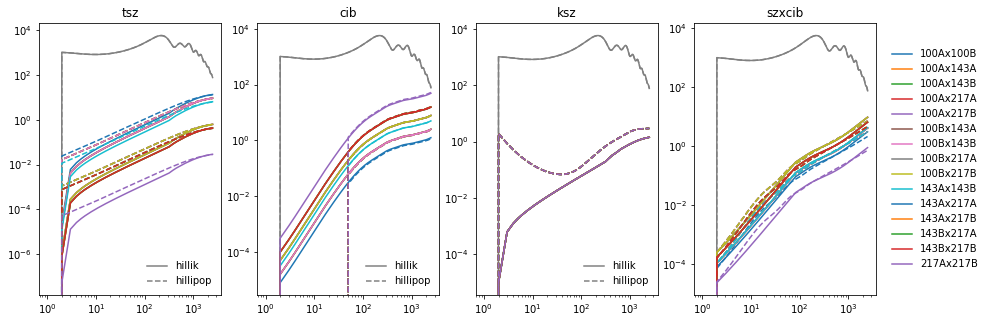

In [31]:
import itertools
xfreq = list(itertools.combinations( ['100A','100B','143A','143B','217A','217B'],2))

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_plk_fgs.npy")))
fg_list = ["dust","tsz","ksz","cib","szxcib","ps_radio","ps_dusty","ps"]
hlp = dict( zip(fg_list,np.load( f"{DBdir}/../hillipop_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','hillipop'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label="%sx%s" % xfreq[c])
        p2=plot( abs(hlp[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### SPT

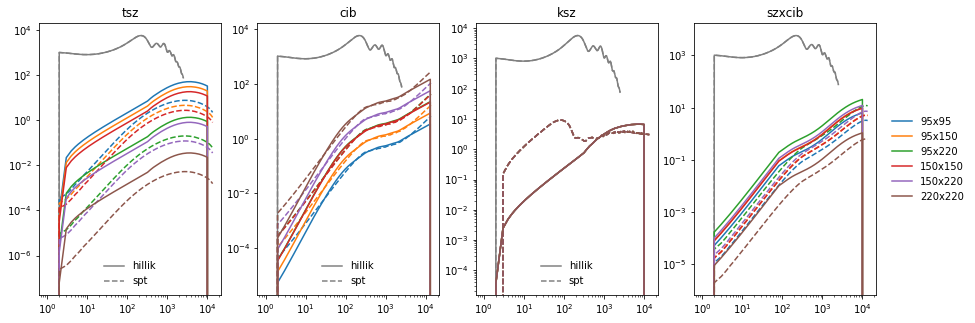

In [30]:
xfreq = ["95x95","95x150","95x220","150x150","150x220","220x220"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_spt_fgs.npy")))
fg_list = ["ps_dg","cib","ps_rg","tsz","ksz","dust","szxcib","szxradio"]
spt = dict( zip(fg_list,np.load( f"{DBdir}/../spt_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','spt'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(spt[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (deep)

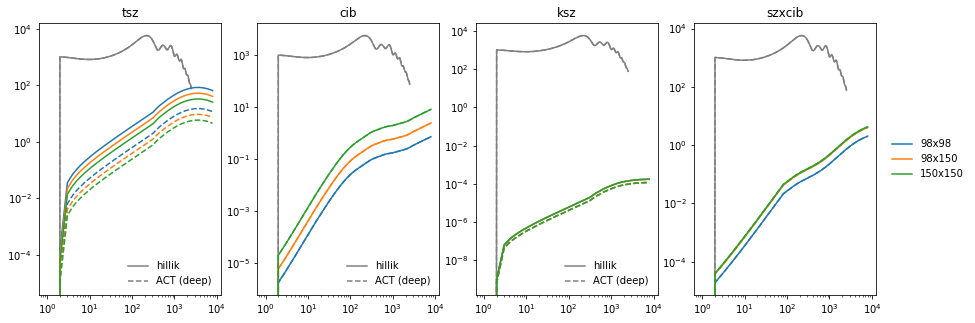

In [28]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTd_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_deep_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (deep)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (wide)

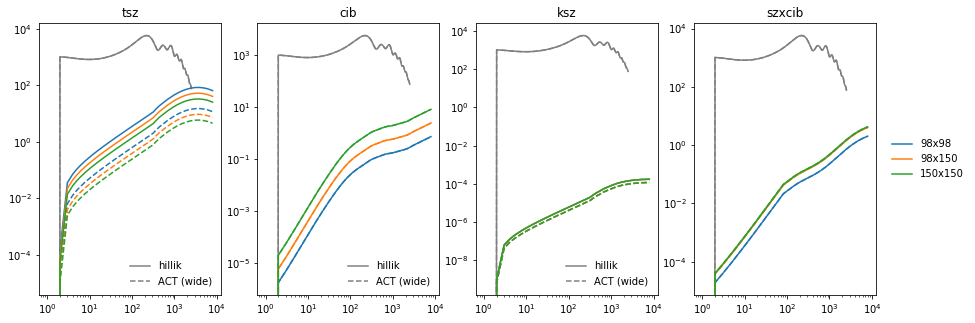

In [29]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTw_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_wide_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (wide)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

## Each survey

In [6]:
runnames = ['hillik_plk','hillik_spt','hillik_act']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8, nelts=20000) for run in runnames]

hillik_plk: 238935  211920  219924  180305 
hillik_spt: 493681  408801  347201  498961 
hillik_act: 318241  352605  263121  329014 


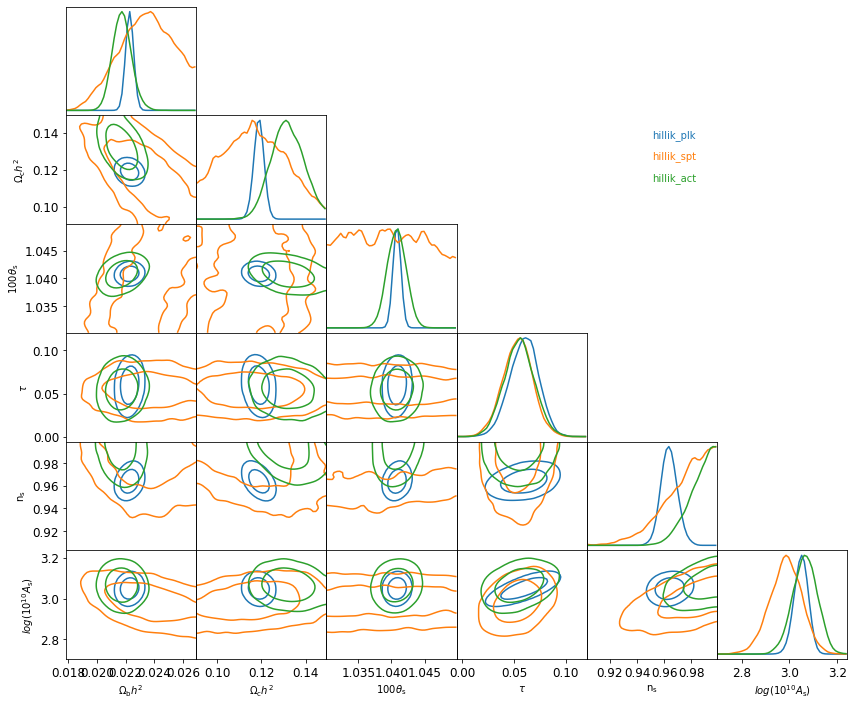

In [7]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

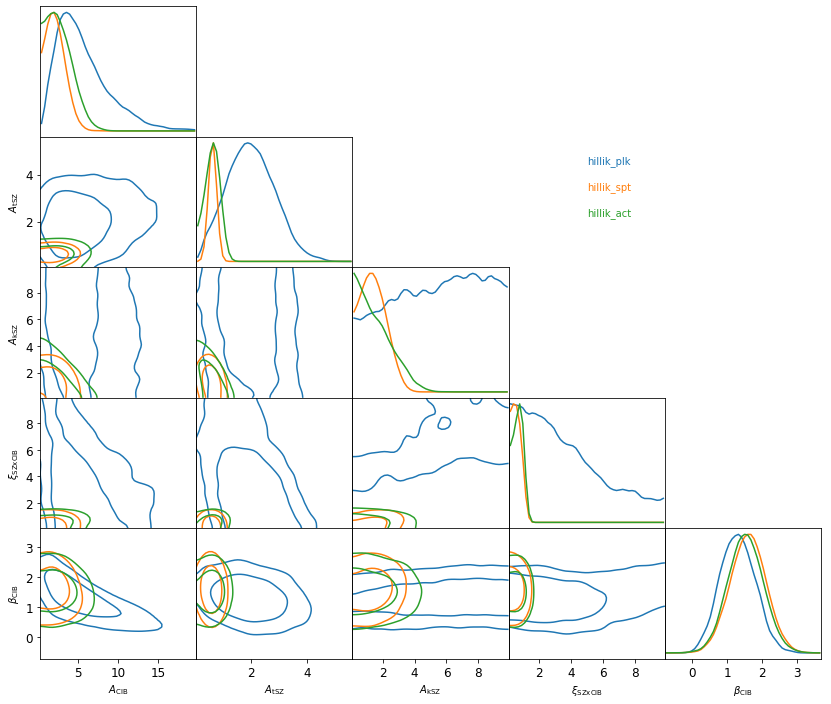

In [8]:
#extra-galactic fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Combination

In [2]:
runnames = ['hillik_plk','hillik_plk_spt','hillik_plk_act','hillik_plk_spt_act']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8, nelts=20000) for run in runnames]

hillik_plk: 240359  213229  221470  181271 
hillik_plk_spt: 708321  436249  376755  601921 
hillik_plk_act: 540376  716883  446944  446720 
hillik_plk_spt_act: 340016  494686  324149  655288 


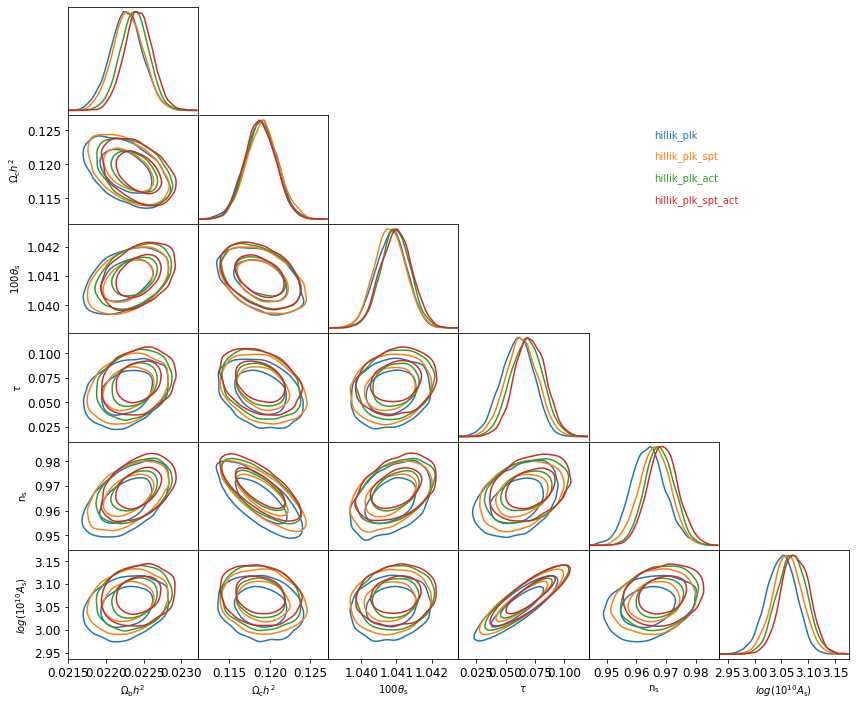

In [3]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

In [4]:
print( "%35s %28s %28s %28s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                         hillik_plk               hillik_plk_spt               hillik_plk_act           hillik_plk_spt_act
ombh2           =  0.022270 +/- 0.000216  |   0.022292 +/- 0.000206  |   0.022377 +/- 0.000189  |   0.022430 +/- 0.000186
omch2           =  0.118912 +/- 0.002031  |   0.119122 +/- 0.002014  |   0.118889 +/- 0.001914  |   0.118775 +/- 0.001938
theta           =  1.040860 +/- 0.000451  |   1.040815 +/- 0.000447  |   1.040973 +/- 0.000422  |   1.041001 +/- 0.000452
tau             =  0.060253 +/- 0.014147  |   0.063528 +/- 0.013959  |   0.068049 +/- 0.013932  |   0.070897 +/- 0.013066
ns              =  0.963981 +/- 0.005862  |   0.966248 +/- 0.005332  |   0.967863 +/- 0.005008  |   0.969020 +/- 0.005082
logA            =  3.050380 +/- 0.027311  |   3.061118 +/- 0.026775  |   3.069682 +/- 0.027181  |   3.075468 +/- 0.025538


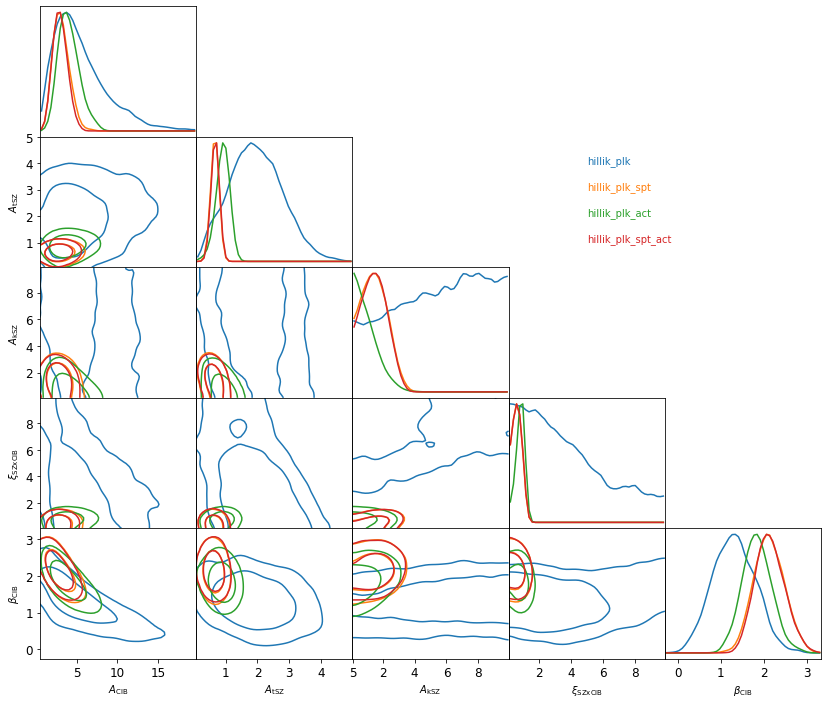

In [5]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Alens

In [2]:
runnames = ['hillik_plk_Alens','hillik_plk_act_Alens','hillik_plk_spt_Alens','hillik_plk_spt_act_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8, nelts=20000) for run in runnames]

hillik_plk_Alens: 213038  184005  147470  204915 
hillik_plk_act_Alens: 449916  311503  530824  366613 
hillik_plk_spt_Alens: 200242  411267  275348  306447 
hillik_plk_spt_act_Alens: 249199  386441  464059  489930 


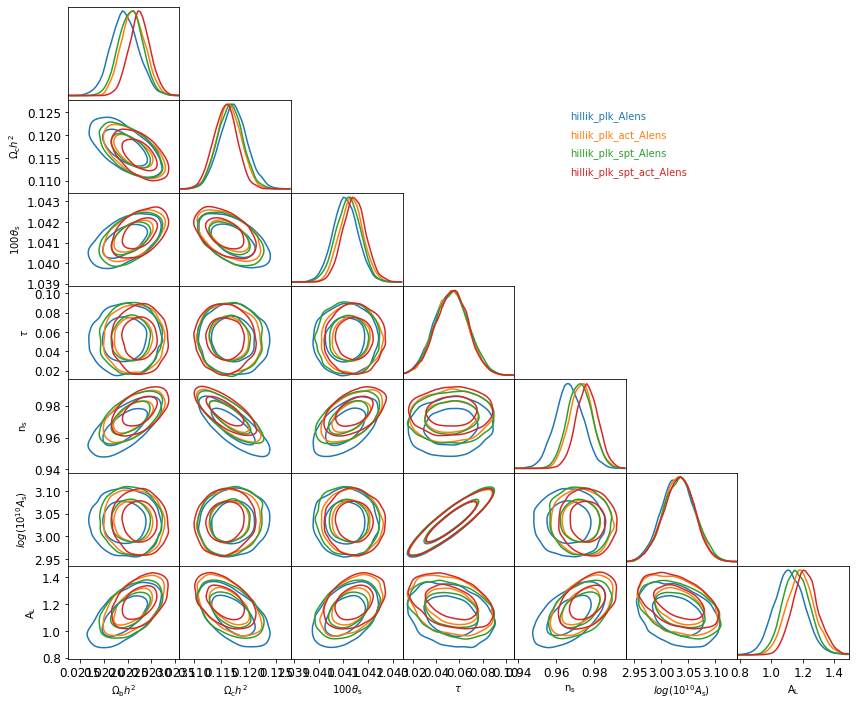

In [3]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.triangle( chains, listpar, labels=runnames)

In [4]:
for i in range(len(chains)):
    m,s = MCtools.MaxPosterior( chains[i], 'Alens', symmetrical=True)
    print("%4.3f +/- %4.3f" % (m,s), "(%4.2fσ)" % ((m-1)/s), runnames[i])

1.115 +/- 0.095 (1.20σ) hillik_plk_Alens
1.185 +/- 0.086 (2.14σ) hillik_plk_act_Alens
1.157 +/- 0.084 (1.87σ) hillik_plk_spt_Alens
1.215 +/- 0.079 (2.72σ) hillik_plk_spt_act_Alens
